## Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries imported successfully.")

Libraries imported successfully.


## Load Dataset

In [2]:
# Extract the dataset zip if the image folder is not already present
if not os.path.exists("Img"):
    if os.path.exists("archive.zip"):
        with zipfile.ZipFile("archive.zip") as z:
            z.extractall(".")

print("Image folder found:", os.path.exists("Img"))
print("Label file found:", os.path.exists("english.csv"))

Image folder found: True
Label file found: True


In [3]:
# english.csv has two columns: the image path and the character label
data = pd.read_csv("english.csv")

print("Number of rows:", len(data))
print("Number of classes:", data["label"].nunique())
data.head()

Number of rows: 3410
Number of classes: 62


,image,label
0,Img/img001-001.png,0
1,Img/img001-002.png,0
2,Img/img001-003.png,0
3,Img/img001-004.png,0
4,Img/img001-005.png,0


In [4]:
# Check how many images belong to each class
counts = data["label"].value_counts()
print("Images per class - min:", counts.min(), "| max:", counts.max())
print("The dataset is balanced, every character has the same number of samples.")

Images per class - min: 55 | max: 55
The dataset is balanced, every character has the same number of samples.


## Display Sample Images

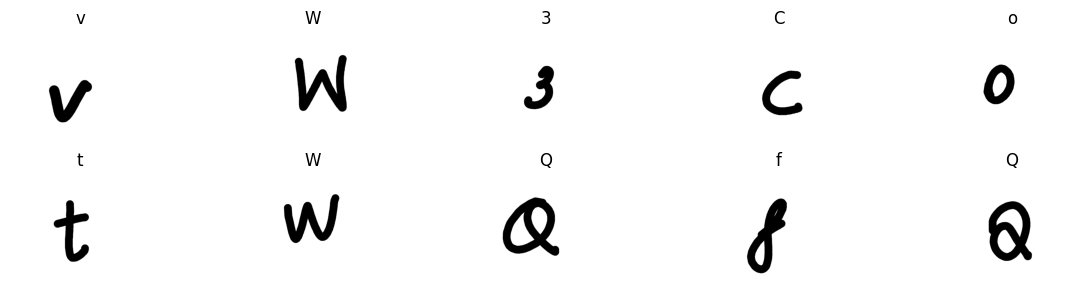

In [5]:
# Show 10 random images with their labels
sample = data.sample(10, random_state=RANDOM_STATE)

plt.figure(figsize=(12, 3))
for i, (path, label) in enumerate(zip(sample["image"], sample["label"])):
    img = Image.open(path)
    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(label)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [6]:
# Check the original size of one image
img = Image.open(data["image"][0])
print("Original image size:", img.size)
print("Original image mode:", img.mode)

Original image size: (1200, 900)
Original image mode: RGB


## Preprocessing

In [7]:
# Convert every image to grayscale, resize to 32x32, and flatten it into a row of 1024 pixels
IMG_SIZE = 32

X = []
for path in data["image"]:
    img = Image.open(path).convert("L").resize((IMG_SIZE, IMG_SIZE))
    X.append(np.array(img, dtype="float32").flatten())

X = np.array(X)
print("Feature matrix shape:", X.shape)

Feature matrix shape: (3410, 1024)


In [8]:
# Normalize pixel values from 0-255 to 0-1
X = X / 255.0
print("Min pixel value:", X.min(), "| Max pixel value:", X.max())
print("Mean pixel value before inverting:", round(X.mean(), 3))

Min pixel value: 0.0 | Max pixel value: 1.0
Mean pixel value before inverting: 0.942


In [9]:
# The images have white paper and dark ink, so most pixels are close to 1.
# We invert them so that the ink becomes 1 and the blank background becomes 0.
X = 1 - X
print("Mean pixel value after inverting:", round(X.mean(), 3))

Mean pixel value after inverting: 0.058


In [10]:
# Encode the 62 character labels (0-9, A-Z, a-z) into numbers 0-61
encoder = LabelEncoder()
y = encoder.fit_transform(data["label"])

print("Number of encoded classes:", len(encoder.classes_))
print("First 10 class names:", list(encoder.classes_[:10]))
print("Example: label", data["label"][0], "is encoded as", y[0])

Number of encoded classes: 62
First 10 class names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Example: label 0 is encoded as 0


## Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Features per sample:", X_train.shape[1])

Training samples: 2728
Testing samples: 682
Features per sample: 1024


## PLA Implementation

In [12]:
# Step activation function: output is 1 if the input is positive, otherwise 0
def step(z):
    return np.where(z > 0, 1.0, 0.0)

print("step(-2.5) =", step(-2.5))
print("step(0.8)  =", step(0.8))

step(-2.5) = 0.0
step(0.8)  = 1.0


In [13]:
# A single perceptron gives only one output, so we train one perceptron per class
# (one-vs-rest). Each perceptron learns to fire for its own character.
n_classes = len(encoder.classes_)
n_features = X_train.shape[1]

# Weight initialization: start with all weights and biases at zero
W = np.zeros((n_classes, n_features))
b = np.zeros(n_classes)

print("Weight matrix shape:", W.shape)
print("Bias vector shape:", b.shape)

Weight matrix shape: (62, 1024)
Bias vector shape: (62,)


In [14]:
# Train the PLA using the perceptron weight update rule: w = w + lr * (y - y_hat) * x
LR_PLA = 0.1
EPOCHS_PLA = 30

pla_errors = []
rng = np.random.RandomState(RANDOM_STATE)

for epoch in range(EPOCHS_PLA):
    order = rng.permutation(len(X_train))   # shuffle the samples each epoch
    mistakes = 0
    for i in order:
        x = X_train[i]
        target = np.zeros(n_classes)
        target[y_train[i]] = 1              # the correct perceptron should output 1

        y_hat = step(W.dot(x) + b)          # prediction of all 62 perceptrons
        update = target - y_hat             # 0 where correct, +1 or -1 where wrong

        if update.any():
            mistakes += 1
        W = W + LR_PLA * np.outer(update, x)
        b = b + LR_PLA * update

    pla_errors.append(mistakes / len(X_train))

print("Training error in epoch 1 :", round(pla_errors[0], 4))
print("Training error in epoch 30:", round(pla_errors[-1], 4))

Training error in epoch 1 : 0.9556
Training error in epoch 30: 0.6525


## PLA Results

In [15]:
# For prediction we pick the perceptron with the highest score
pla_scores_test = X_test.dot(W.T) + b
pla_pred = np.argmax(pla_scores_test, axis=1)

pla_train_pred = np.argmax(X_train.dot(W.T) + b, axis=1)

pla_acc = accuracy_score(y_test, pla_pred)
print("PLA training accuracy:", round(accuracy_score(y_train, pla_train_pred), 4))
print("PLA testing accuracy :", round(pla_acc, 4))

PLA training accuracy: 0.6455
PLA testing accuracy : 0.2111


In [16]:
# Macro averaging is used because all 62 classes have the same number of samples
pla_prec = precision_score(y_test, pla_pred, average="macro", zero_division=0)
pla_rec = recall_score(y_test, pla_pred, average="macro", zero_division=0)
pla_f1 = f1_score(y_test, pla_pred, average="macro", zero_division=0)

print("PLA Precision (macro):", round(pla_prec, 4))
print("PLA Recall (macro)   :", round(pla_rec, 4))
print("PLA F1-score (macro) :", round(pla_f1, 4))

PLA Precision (macro): 0.2558
PLA Recall (macro)   : 0.2111
PLA F1-score (macro) : 0.2016


## MLP Model

In [17]:
# A simple starting MLP: one hidden layer of 256 neurons, ReLU activation,
# cross-entropy loss (used by default for classification) and the Adam optimizer
base_mlp = MLPClassifier(hidden_layer_sizes=(256,),
                         activation="relu",
                         solver="adam",
                         learning_rate_init=0.001,
                         batch_size=32,
                         max_iter=50,
                         random_state=RANDOM_STATE)
base_mlp.fit(X_train, y_train)

print("Baseline MLP test accuracy:", round(base_mlp.score(X_test, y_test), 4))

Baseline MLP test accuracy: 0.4765


## Hyperparameter Tuning

In [18]:
# We try a few reasonable settings and change one thing at a time so we can see
# what each hyperparameter does. max_iter is kept at 50 to keep the tuning fast.
configs = [
    {"hidden_layer_sizes": (256,),        "activation": "relu",     "solver": "adam", "learning_rate_init": 0.001, "batch_size": 32},
    {"hidden_layer_sizes": (256,),        "activation": "tanh",     "solver": "adam", "learning_rate_init": 0.001, "batch_size": 32},
    {"hidden_layer_sizes": (256,),        "activation": "logistic", "solver": "adam", "learning_rate_init": 0.001, "batch_size": 32},
    {"hidden_layer_sizes": (256,),        "activation": "relu",     "solver": "sgd",  "learning_rate_init": 0.01,  "batch_size": 32},
    {"hidden_layer_sizes": (256,),        "activation": "relu",     "solver": "adam", "learning_rate_init": 0.01,  "batch_size": 32},
    {"hidden_layer_sizes": (256,),        "activation": "relu",     "solver": "adam", "learning_rate_init": 0.001, "batch_size": 64},
    {"hidden_layer_sizes": (512, 256),    "activation": "relu",     "solver": "adam", "learning_rate_init": 0.001, "batch_size": 32},
    {"hidden_layer_sizes": (256, 128, 64),"activation": "relu",     "solver": "adam", "learning_rate_init": 0.001, "batch_size": 32},
]

rows = []
loss_curves = {}

for cfg in configs:
    model = MLPClassifier(max_iter=50, random_state=RANDOM_STATE, **cfg)
    model.fit(X_train, y_train)

    name = f"{cfg['hidden_layer_sizes']}-{cfg['activation']}-{cfg['solver']}-lr{cfg['learning_rate_init']}-bs{cfg['batch_size']}"
    loss_curves[name] = model.loss_curve_

    rows.append([str(cfg["hidden_layer_sizes"]), cfg["activation"], cfg["solver"],
                 cfg["learning_rate_init"], cfg["batch_size"],
                 round(model.score(X_train, y_train), 4),
                 round(model.score(X_test, y_test), 4)])

tuning = pd.DataFrame(rows, columns=["Hidden Layers", "Activation", "Optimizer",
                                     "Learning Rate", "Batch Size",
                                     "Train Accuracy", "Test Accuracy"])
tuning

,Hidden Layers,Activation,Optimizer,Learning Rate,Batch Size,Train Accuracy,Test Accuracy
0,"(256,)",relu,adam,0.001,32,0.9989,0.4765
1,"(256,)",tanh,adam,0.001,32,0.9938,0.4150
2,"(256,)",logistic,adam,0.001,32,0.8790,0.4692
3,"(256,)",relu,sgd,0.010,32,0.9853,0.4736
4,"(256,)",relu,adam,0.010,32,0.9861,0.4413
5,"(256,)",relu,adam,0.001,64,0.9941,0.4707
6,"(512, 256)",relu,adam,0.001,32,1.0000,0.5484
7,"(256, 128, 64)",relu,adam,0.001,32,0.9960,0.5161


In [19]:
# Sort the results to see which configuration worked best
tuning.sort_values("Test Accuracy", ascending=False)

,Hidden Layers,Activation,Optimizer,Learning Rate,Batch Size,Train Accuracy,Test Accuracy
6,"(512, 256)",relu,adam,0.001,32,1.0000,0.5484
7,"(256, 128, 64)",relu,adam,0.001,32,0.9960,0.5161
0,"(256,)",relu,adam,0.001,32,0.9989,0.4765
3,"(256,)",relu,sgd,0.010,32,0.9853,0.4736
5,"(256,)",relu,adam,0.001,64,0.9941,0.4707
2,"(256,)",logistic,adam,0.001,32,0.8790,0.4692
4,"(256,)",relu,adam,0.010,32,0.9861,0.4413
1,"(256,)",tanh,adam,0.001,32,0.9938,0.4150


## Best MLP Configuration

In [20]:
best_row = tuning.loc[tuning["Test Accuracy"].idxmax()]

print("Final selected MLP hyperparameters")
print("----------------------------------")
print("Hidden layers   :", best_row["Hidden Layers"])
print("Activation      :", best_row["Activation"])
print("Loss function   : Cross-Entropy (multi-class)")
print("Optimizer       :", best_row["Optimizer"])
print("Learning rate   :", best_row["Learning Rate"])
print("Batch size      :", best_row["Batch Size"])
print("Tuning accuracy :", best_row["Test Accuracy"])

Final selected MLP hyperparameters
----------------------------------
Hidden layers   : (512, 256)
Activation      : relu
Loss function   : Cross-Entropy (multi-class)
Optimizer       : adam
Learning rate   : 0.001
Batch size      : 32
Tuning accuracy : 0.5484


## MLP Results

In [21]:
# Train the chosen configuration for more epochs so it converges properly
best_mlp = MLPClassifier(hidden_layer_sizes=(512, 256),
                         activation="relu",
                         solver="adam",
                         learning_rate_init=0.001,
                         batch_size=32,
                         max_iter=150,
                         random_state=RANDOM_STATE)
best_mlp.fit(X_train, y_train)

print("Epochs actually run:", best_mlp.n_iter_)
print("Final training loss:", round(best_mlp.loss_curve_[-1], 4))

Epochs actually run: 59
Final training loss: 0.0072


In [22]:
mlp_pred = best_mlp.predict(X_test)
mlp_proba = best_mlp.predict_proba(X_test)

mlp_acc = accuracy_score(y_test, mlp_pred)
mlp_prec = precision_score(y_test, mlp_pred, average="macro", zero_division=0)
mlp_rec = recall_score(y_test, mlp_pred, average="macro", zero_division=0)
mlp_f1 = f1_score(y_test, mlp_pred, average="macro", zero_division=0)

print("MLP training accuracy:", round(best_mlp.score(X_train, y_train), 4))
print("MLP testing accuracy :", round(mlp_acc, 4))
print("MLP Precision (macro):", round(mlp_prec, 4))
print("MLP Recall (macro)   :", round(mlp_rec, 4))
print("MLP F1-score (macro) :", round(mlp_f1, 4))

MLP training accuracy: 1.0
MLP testing accuracy : 0.5499
MLP Precision (macro): 0.5715
MLP Recall (macro)   : 0.5499
MLP F1-score (macro) : 0.5498


## Confusion Matrices

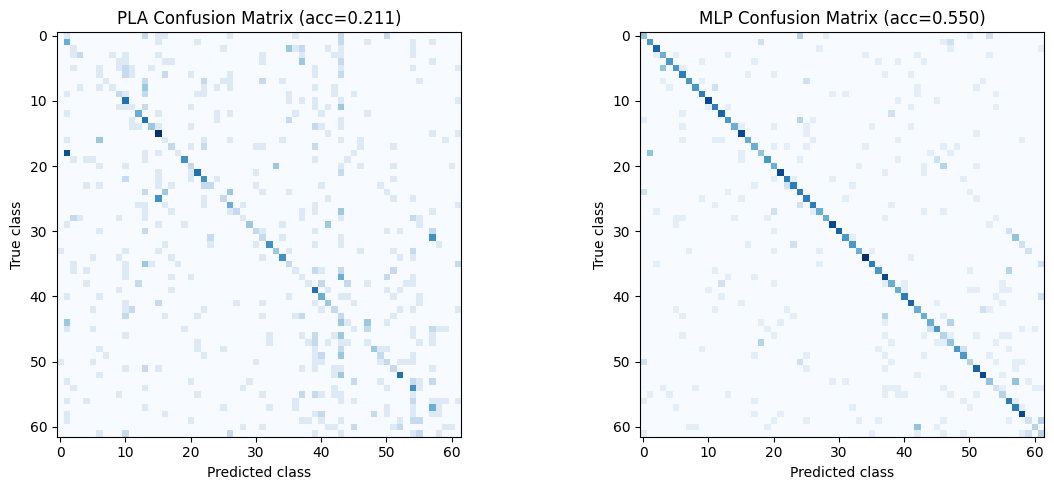

In [23]:
# With 62 classes the matrix is large, so we show it as an image instead of numbers.
# A good model should show a bright diagonal line.
cm_pla = confusion_matrix(y_test, pla_pred)
cm_mlp = confusion_matrix(y_test, mlp_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cm_pla, cmap="Blues")
axes[0].set_title(f"PLA Confusion Matrix (acc={pla_acc:.3f})")
axes[1].imshow(cm_mlp, cmap="Blues")
axes[1].set_title(f"MLP Confusion Matrix (acc={mlp_acc:.3f})")
for ax in axes:
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
plt.tight_layout()
plt.show()

In [24]:
# Count how many test samples were placed on the diagonal (correct predictions)
print("PLA correct predictions:", np.trace(cm_pla), "out of", cm_pla.sum())
print("MLP correct predictions:", np.trace(cm_mlp), "out of", cm_mlp.sum())

PLA correct predictions: 144 out of 682
MLP correct predictions: 375 out of 682


## ROC Curves

In [25]:
# For multiclass ROC we turn the labels into a one-hot matrix (one column per class)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))
print("Binarized label shape:", y_test_bin.shape)

Binarized label shape: (682, 62)


In [26]:
def micro_macro_roc(y_bin, scores):
    # micro average: pool every class decision together into one big binary problem
    fpr_micro, tpr_micro, _ = roc_curve(y_bin.ravel(), scores.ravel())
    auc_micro = auc(fpr_micro, tpr_micro)

    # macro average: compute the ROC for each class, then average them
    all_fpr = np.linspace(0, 1, 100)
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(y_bin.shape[1]):
        fpr_i, tpr_i, _ = roc_curve(y_bin[:, i], scores[:, i])
        mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)
    mean_tpr = mean_tpr / y_bin.shape[1]
    auc_macro = auc(all_fpr, mean_tpr)

    return fpr_micro, tpr_micro, auc_micro, all_fpr, mean_tpr, auc_macro

# PLA has no probabilities, so we use its raw perceptron scores
pla_roc = micro_macro_roc(y_test_bin, pla_scores_test)
mlp_roc = micro_macro_roc(y_test_bin, mlp_proba)

print("PLA micro AUC:", round(pla_roc[2], 4), "| PLA macro AUC:", round(pla_roc[5], 4))
print("MLP micro AUC:", round(mlp_roc[2], 4), "| MLP macro AUC:", round(mlp_roc[5], 4))

PLA micro AUC: 0.8115 | PLA macro AUC: 0.8126
MLP micro AUC: 0.9576 | MLP macro AUC: 0.9577


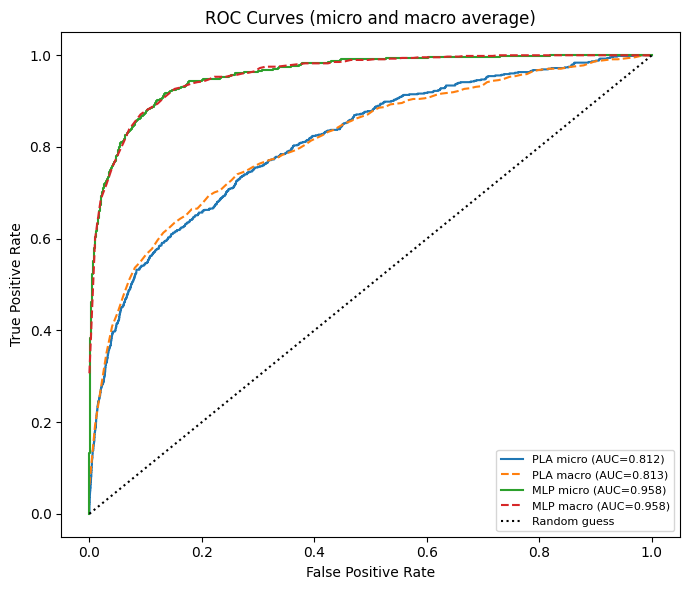

In [27]:
plt.figure(figsize=(7, 6))
plt.plot(pla_roc[0], pla_roc[1], label=f"PLA micro (AUC={pla_roc[2]:.3f})")
plt.plot(pla_roc[3], pla_roc[4], "--", label=f"PLA macro (AUC={pla_roc[5]:.3f})")
plt.plot(mlp_roc[0], mlp_roc[1], label=f"MLP micro (AUC={mlp_roc[2]:.3f})")
plt.plot(mlp_roc[3], mlp_roc[4], "--", label=f"MLP macro (AUC={mlp_roc[5]:.3f})")
plt.plot([0, 1], [0, 1], "k:", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (micro and macro average)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Training Error/Loss Curves

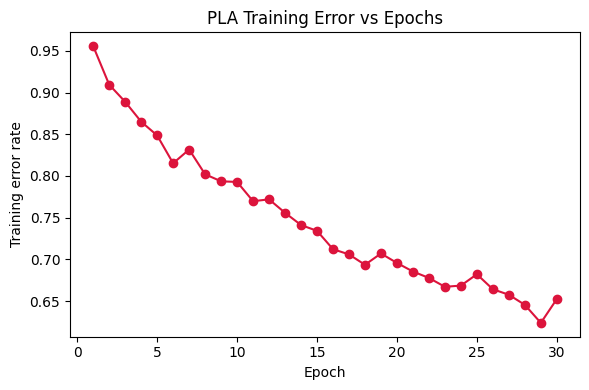

In [28]:
# PLA training error per epoch (fraction of samples that caused a weight update)
plt.figure(figsize=(6, 4))
plt.plot(range(1, EPOCHS_PLA + 1), pla_errors, marker="o", color="crimson")
plt.xlabel("Epoch")
plt.ylabel("Training error rate")
plt.title("PLA Training Error vs Epochs")
plt.tight_layout()
plt.show()

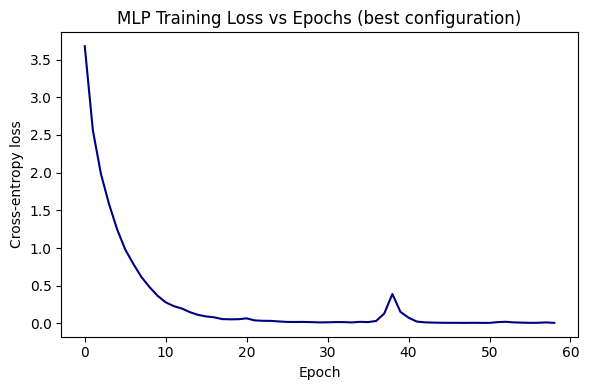

In [29]:
# MLP cross-entropy loss per epoch
plt.figure(figsize=(6, 4))
plt.plot(best_mlp.loss_curve_, color="navy")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("MLP Training Loss vs Epochs (best configuration)")
plt.tight_layout()
plt.show()

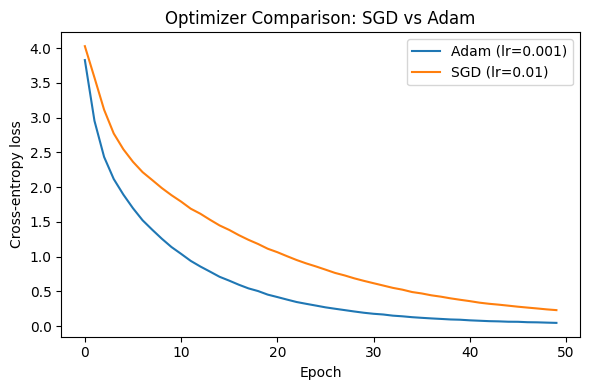

In [30]:
# Compare how quickly SGD and Adam bring the loss down (same network, 50 epochs)
adam_key = "(256,)-relu-adam-lr0.001-bs32"
sgd_key = "(256,)-relu-sgd-lr0.01-bs32"

plt.figure(figsize=(6, 4))
plt.plot(loss_curves[adam_key], label="Adam (lr=0.001)")
plt.plot(loss_curves[sgd_key], label="SGD (lr=0.01)")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Optimizer Comparison: SGD vs Adam")
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
# The best MLP reaches almost zero training loss, which is a sign of overfitting.
# Here we retrain it with L2 regularization (alpha) and early stopping to reduce it.
reg_mlp = MLPClassifier(hidden_layer_sizes=(512, 256),
                        activation="relu",
                        solver="adam",
                        learning_rate_init=0.001,
                        batch_size=32,
                        alpha=0.01,
                        early_stopping=True,
                        validation_fraction=0.15,
                        n_iter_no_change=10,
                        max_iter=150,
                        random_state=RANDOM_STATE)
reg_mlp.fit(X_train, y_train)

print("Without regularization -> train:", round(best_mlp.score(X_train, y_train), 4),
      "| test:", round(mlp_acc, 4),
      "| gap:", round(best_mlp.score(X_train, y_train) - mlp_acc, 4))
print("With regularization    -> train:", round(reg_mlp.score(X_train, y_train), 4),
      "| test:", round(reg_mlp.score(X_test, y_test), 4),
      "| gap:", round(reg_mlp.score(X_train, y_train) - reg_mlp.score(X_test, y_test), 4))

Without regularization -> train: 1.0 | test: 0.5499 | gap: 0.4501


With regularization    -> train: 0.9263 | test: 0.5073 | gap: 0.419


## PLA vs MLP Comparison

In [32]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (macro)", "Recall (macro)", "F1-score (macro)",
               "ROC-AUC (micro)", "ROC-AUC (macro)"],
    "PLA": [round(pla_acc, 4), round(pla_prec, 4), round(pla_rec, 4), round(pla_f1, 4),
            round(pla_roc[2], 4), round(pla_roc[5], 4)],
    "MLP": [round(mlp_acc, 4), round(mlp_prec, 4), round(mlp_rec, 4), round(mlp_f1, 4),
            round(mlp_roc[2], 4), round(mlp_roc[5], 4)],
})
comparison

,Metric,PLA,MLP
0,Accuracy,0.2111,0.5499
1,Precision (macro),0.2558,0.5715
2,Recall (macro),0.2111,0.5499
3,F1-score (macro),0.2016,0.5498
4,ROC-AUC (micro),0.8115,0.9576
5,ROC-AUC (macro),0.8126,0.9577


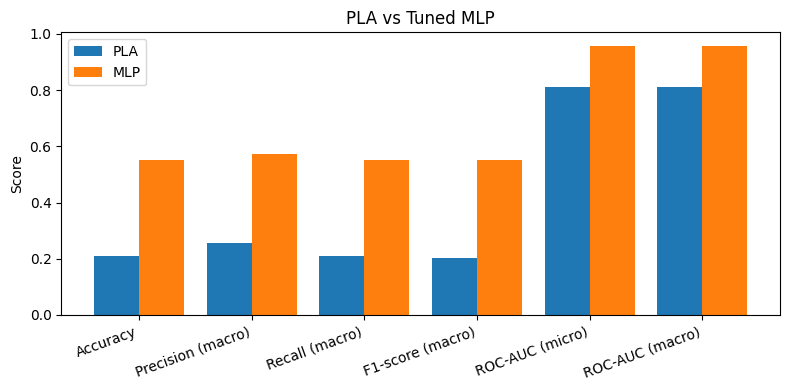

In [33]:
plt.figure(figsize=(8, 4))
x_pos = np.arange(len(comparison))
plt.bar(x_pos - 0.2, comparison["PLA"], width=0.4, label="PLA")
plt.bar(x_pos + 0.2, comparison["MLP"], width=0.4, label="MLP")
plt.xticks(x_pos, comparison["Metric"], rotation=20, ha="right")
plt.ylabel("Score")
plt.title("PLA vs Tuned MLP")
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
# Effect of each hyperparameter change on test accuracy, relative to the baseline row
base_acc = tuning.loc[0, "Test Accuracy"]
impact = tuning.copy()
impact["Change vs Baseline"] = (impact["Test Accuracy"] - base_acc).round(4)
impact[["Hidden Layers", "Activation", "Optimizer", "Learning Rate",
        "Batch Size", "Test Accuracy", "Change vs Baseline"]]

,Hidden Layers,Activation,Optimizer,Learning Rate,Batch Size,Test Accuracy,Change vs Baseline
0,"(256,)",relu,adam,0.001,32,0.4765,0.0000
1,"(256,)",tanh,adam,0.001,32,0.4150,-0.0615
2,"(256,)",logistic,adam,0.001,32,0.4692,-0.0073
3,"(256,)",relu,sgd,0.010,32,0.4736,-0.0029
4,"(256,)",relu,adam,0.010,32,0.4413,-0.0352
5,"(256,)",relu,adam,0.001,64,0.4707,-0.0058
6,"(512, 256)",relu,adam,0.001,32,0.5484,0.0719
7,"(256, 128, 64)",relu,adam,0.001,32,0.5161,0.0396
